# Päivystyksen käyntimäärän ennustaminen eksponentiaalisella tasoituksella (PROC ESM)


## Yhteenveto

Keskisuuri sairaalajärjestelmä tarvitsee vuoden mittaisen ennusteen päivystyksen (ED) kuukausittaisesta käyntimäärästä suunnitellakseen hoitajien miehityksen ja vuodepaikkakapasiteetin ennen talven hengitystieinfektioiden ryntäystä. Tämä muistikirja rakentaa synteettisen neljän vuoden kuukausittaisen päivystystilaston (48 kuukautta, tammikuu 2021 - joulukuu 2024) ja sovittaa Wintersin multiplikatiivisen kausivaihtelumallin **PROC ESM** -proseduurilla tuottaakseen 12 kuukauden ennusteen 95 %:n ennustusväleillä.

Sovitettu malli kuvaa sarjan hyvin: näytteensisäinen **RMSE on noin 320 käyntiä** ja **MAPE on 4,16 %**, joten tyypillinen kuukausittainen virhe on alle 5 % käyntimäärästä. Ennuste projisoi tutun kausivaihtelun muodon vuoteen 2025 - joulukuun ja helmikuun välinen huippu on lähellä **7 300-7 800 käyntiä/kk** ja loppukesän pohja lähellä **5 800-5 900** - ja ennustusvyöhykkeet levenevät horisontin pidentyessä. Nuo luvut ja niiden taustalla olevat tasoituspainot luetaan suoraan proseduurin tulostietojoukoista alla.


## Tietolähteet

| Tietojoukko | Rivejä | Rakeisuus | Keskeiset muuttujat | Kuvaus |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Yksi rivi kalenterikuukautta kohti, tammikuu 2021 - joulukuu 2024 | `month` (kuukausittainen SAS-päivämäärä), `ed_visits` (kokonaislukuna päivystyksen kuukausittainen käyntimäärä) | Synteettinen kuukausittainen päivystyksen käyntimäärä keskisuurelle sairaalajärjestelmälle. Muodostettu nousevalla kasvutrendillä (~3 % vuodessa), multiplikatiivisella kausisyklillä, joka huipentuu talven hengitystieinfektiokaudella (joulu-helmikuu) ja notkahtaa loppukesällä, sekä log-normaalilla kohinalla, jotta kausivaihtelun amplitudi skaalautuu nousevan tason mukana. |


# Päivystyksen käyntimäärän ennustaminen PROC ESM -proseduurilla

Kapasiteetin suunnittelijoiden on tiedettävä, kuinka monta päivystyskäyntiä odottaa kuukausittain, jotta he voivat aikatauluttaa hoitajat, varata joustovuoteita ja valmistella hengitystietarvikkeet ennen talven ryntäystä. Päivystyksen käyntimäärä on oppikirjaesimerkki kausivaihtelevasta aikasarjasta: se kasvaa hitaasti vuosi vuodelta, huipentuu joulu-helmikuun hengitystieinfektiokaudella ja laskee loppukesällä, ja kausivaihtelun suuruus kasvaa perustason käyntimäärän kasvaessa. Juuri tämän multiplikatiivisen kausirakenteen **PROC ESM** -proseduurin Wintersin multiplikatiivinen menetelmä on suunniteltu tavoittamaan.

Tässä muistikirjassa me:

1. Muodostamme realistisen neljän vuoden kuukausittaisen päivystystilaston, jossa on trendi, multiplikatiivinen kausivaihtelu ja kohina.
2. Visualisoimme sarjan vahvistaaksemme sen multiplikatiivisen kausirakenteen.
3. Sovitamme Wintersin multiplikatiivisen mallin PROC ESM -proseduurilla ja luemme sen tasoituspainot ja sovitustunnusluvut tulostietojoukoista.
4. Tuotamme 12 kuukauden ennusteen 95 %:n ennustusväleillä ja tulkitsemme operatiiviset seuraukset.


## Vaihe 1 - Muodosta synteettinen kuukausittainen päivystystilasto

Rakennamme 48 kuukausittaista havaintoa tammikuusta 2021 joulukuuhun 2024. Kunkin kuukauden odotettu käyntimäärä on perustaso, joka kasvaa noin 3 % vuodessa, kerrottuna kausi-indeksillä (korkein keskitalvella, matalin loppukesällä) ja häirittynä log-normaalilla kohinalla, jotta satunnaisvaihtelu skaalautuu tason mukana. `intnx` siirtää kuukauteen kohdistuvaa päivämäärää yhden jakson riviä kohti, ja `streaminit` tekee arvonnasta toistettavan.


In [1]:
TIEDOT ed_census;
    CALL streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    TAULUKKO seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    MUOTO month yymmn6.;
    TEE i = 1 ASTI 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        TULOSTE;
    LOPPU;
    SÄILYTÄ month ed_visits;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=ed_census(obs=14) noobs NIMIKE;
    NIMIKE month = 'Kuukausi' ed_visits = 'Päivystyskäynnit';
    OTSIKKO 'Synteettisen päivystyskäyntimäärän ensimmäiset 14 kuukautta';
SUORITA;


                              Synteettisen päivystyskäyntimäärän ensimmäiset 14 kuukautta                               

Kuukausi    Päivystyskäynnit
  202101                7103
  202102                6835
  202103                6668
  202104                5611
  202105                5816
  202106                5383
  202107                5586
  202108                5283
  202109                5161
  202110                6109
  202111                6451
  202112                6730
  202201                6847
  202202                7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


Ensimmäiset kuukaudet vahvistavat rakenteen: käyntimäärä avautuu lähellä 7 100:aa tammikuun 2021 huipussa, laskee kevään ja kesän aikana elo-syyskuun pohjaansa ja kiipeää sitten takaisin seuraavaan talveen. Tammikuuhun 2022 mennessä huippu on noussut noin 6 800-7 200:aan, mikä heijastaa kausisykliin kerrostuvaa ~3 %:n vuosikasvua.


## Vaihe 2 - Visualisoi sarja

Ennen mallintamista piirrä raaka sarja vahvistaaksesi odottamamme rakenteen: loiva nouseva trendi, jossa toistuu vuosittainen huippu joka talvi ja jonka amplitudi levenee ajan myötä. Leveenevä kausivaihtelu on *multiplikatiivisen* kausiprosessin tunnusmerkki ja kertoo meille, mikä ESM-malli valita.


                              Synteettisen päivystyskäyntimäärän ensimmäiset 14 kuukautta                               




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


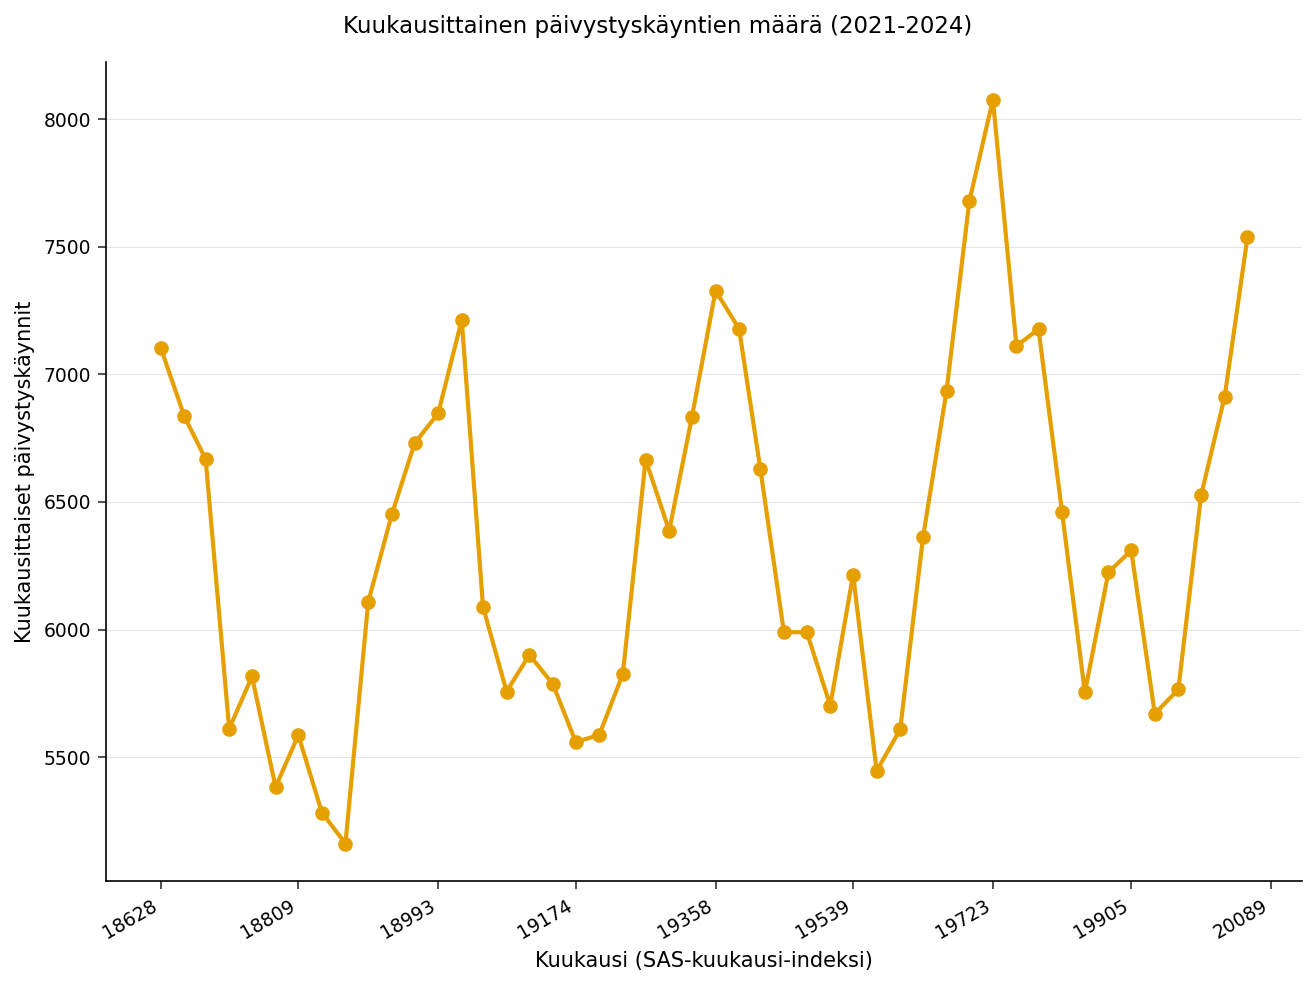

In [2]:
PROSEDUURI SGPLOT TIEDOT=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS NIMIKE='Kuukausi (SAS-kuukausi-indeksi)';
    YAXIS NIMIKE='Kuukausittaiset päivystyskäynnit' grid;
    OTSIKKO 'Kuukausittainen päivystyskäyntien määrä (2021-2024)';
SUORITA;


Kuvaaja näyttää neljä selkeää vuosisykliä. Kukin talven huippu asettuu hieman edellistä korkeammalle, kohoten noin 7 100:sta vuonna 2021 noin 8 100:aan vuoden 2024 huipussa, kun taas kesän pohjat nousevat vaatimattomammin - kausivaihtelu kasvaa tason mukana. Tuo leveenevä amplitudi on multiplikatiivisen kausivaihtelun tunnusmerkki ja perustelee `MODEL=WINTERS` (Wintersin multiplikatiivinen) valinnan seuraavassa vaiheessa.


## Vaihe 3 - Sovita Wintersin multiplikatiivinen malli

Sovitamme Wintersin multiplikatiivisen kausitasoituksen koko 48 kuukauden historiaan. `ID`-lause määrittää `month`-muuttujan aikaindeksiksi `MONTH`-välillä, ja `FORECAST`-lause pyytää `MODEL=WINTERS` yhdessä `LEAD=12`:n kanssa projisoidakseen vuoden eteenpäin. Tallennamme kolme tulostietojoukkoa:

- `OUT=` - historiallinen sarja ennusteen liitettynä (yksi `ed_visits`-sarake), aikatunnus jatkettuna ennustehorisontin yli - ihanteellinen kuvaamiseen.
- `OUTFOR=` - jaksokohtaiset ennustekomponentit: pisteennuste (`PREDICT`) ja ala-/ylärajat ennustukselle.
- `OUTSUM=` - mallin sovitustunnusluvut (RMSE, MAE, MAPE, AIC) ja tasoituspainot yhdellä yhteenvetorivillä.

`ALPHA=0.05` tuottaa 95 %:n ennustusrajat, jotka soveltuvat kapasiteettisuunnittelun riskimarginaaleihin. `PRINT=(STATISTICS)` toistaa sovitustunnusluvut ja tasoituspainot listaukseen.


In [3]:
PROSEDUURI esm TIEDOT=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        TULOSTA=(statistics);
    id month interval=month;
    forecast ed_visits / MODEL=winters ALPHA=0.05;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=esm_summary noobs NIMIKE;
    NIMIKE rmse='RMSE' mae='MAE' mape='MAPE'
          ALPHA='Taso (alfa)' beta='Trendi (beeta)' gamma='Kausivaihtelu (gamma)';
    MUUTTUJA rmse mae mape ALPHA beta gamma;
    OTSIKKO 'Wintersin sovitustilastot ja tasoituspainot';
SUORITA;


                              Synteettisen päivystyskäyntimäärän ensimmäiset 14 kuukautta                               


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                      Wintersin sovitustilastot ja tasoituspainot                                       

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


`OUTSUM=`-rivi ja tulostetut tunnusluvut ovat yhtä mieltä: Wintersin multiplikatiivinen sovitus saavuttaa näytteensisäisen **RMSE:n 320,4 käyntiä**, **MAE:n 264,4** ja **MAPE:n 4,16 %** - tyypillinen kuukausittainen virhe on selvästi alle 5 % käyntimäärästä, mikä on mukavan tarkka miehityssuunnitteluun. Tasoituspainot ovat **alpha = 0,30** (taso), **beta = 0,10** (trendi) ja **gamma = 0,10** (kausi). Kohtalainen tasopaino antaa perustason ajautua ylöspäin potilasväestön kasvun mukana, kun taas pienet trendi- ja kausipainot heijastavat sitä, että kasvuvauhti ja talven ryntäyksen muoto ovat vakaita vuodesta toiseen eikä niihin pidä ylireagoida kuukaudesta toiseen.

> Huomaa: nämä ovat *näytteensisäisiä* sovitustunnuslukuja, jotka on laskettu estimointiotoksesta, eivät näytteen ulkopuolisesta pidätysotoksesta. Ne kvantifioivat, kuinka tarkasti malli seuraa historiaa, johon se sovitettiin.


## Vaihe 4 - Kokoa ja taulukoi 12 kuukauden ennuste

`OUTFOR=`-tietojoukko sisältää pisteennusteen ja ennustusrajat jokaiselle jaksolle, kun taas `OUT=`-tietojoukko kantaa aikatunnuksen siististi jatkettuna ennustehorisontin yli. Kohdistamme nämä kaksi havaintojärjestyksen mukaan liittääksemme ennustepäivämäärät ennustusrajoihin ja säilytämme sitten vain 12 ennustekuukautta. Nämä ovat luvut, joiden mukaan miehityskomitea toimisi.


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
TIEDOT out_idx;
    ASETA ed_with_forecast;
    row = _n_;
    NIMEÄ_UUDELLEEN month = fdate ed_visits = series_value;
SUORITA;

TIEDOT for_idx;
    ASETA esm_forecast;
    row = _n_;
    NIMEÄ_UUDELLEEN ed_visits = observed;
    SÄILYTÄ row observed predict LOWER UPPER;
SUORITA;

TIEDOT forecast_path;
    YHDISTÄ out_idx for_idx;
    MUKAAN row;
    MUOTO fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
SUORITA;

TIEDOT forecast_horizon;
    ASETA forecast_path;
    MISSÄ observed = .;   /* forecast months only (no observed value) */
    SÄILYTÄ fdate predict LOWER UPPER;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=forecast_horizon noobs NIMIKE;
    NIMIKE fdate   = 'Kuukausi'
          predict = 'Ennustetut käynnit'
          LOWER   = '95 % alaraja'
          UPPER   = '95 % yläraja';
    OTSIKKO '12 kuukauden paivystyskayntien ennuste 95 %:n ennusterajoin';
SUORITA;


                              12 kuukauden paivystyskayntien ennuste 95 %:n ennusterajoin                               

Kuukausi   Ennustetut käynnit  95 % alaraja   95 % yläraja
  202501                7,822         7,194          8,450
  202502                7,539         6,651          8,427
  202503                7,292         6,204          8,380
  202504                6,263         5,007          7,519
  202505                6,397         4,992          7,801
  202506                6,039         4,501          7,578
  202507                6,236         4,574          7,897
  202508                5,867         4,091          7,644
  202509                5,802         3,918          7,686
  202510                6,804         4,818          8,790
  202511                7,173         5,090          9,256
  202512                7,567         5,391          9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


Ennuste kantaa kausivaihtelun tunnusmerkin eteenpäin vuoteen 2025. Malli projisoi tammikuun 2025 huipun noin **7 822 käyntiin** (95 %:n väli 7 194-8 450), laantuu kevään aikana, pohjautuu loppukesän pohjaan lähelle **5 802:ta** syyskuussa (väli 3 918-7 686) ja rakentuu sitten uudelleen joulukuun huippuun, joka on suunnilleen **7 567** (väli 5 391-9 742). Ennustusvyöhyke levenee tasaisesti horisontin myötä - ensi kuukauden väli kattaa noin +/-630 käyntiä, kun taas ensi joulukuun väli kattaa yli +/-2 000 - suora muistutus siitä, että lähiajan suunnitelmat ovat paljon vankempia kuin vuoden lopun.


## Vaihe 5 - Piirrä historia sekä ennuste

Lopuksi laitamme ennusteen havaitun historian päälle, jotta suunnittelijat näkevät projisoidun talven huipun ja levenevän epävarmuusvyöhykkeen horisontin pidentyessä. Jaamme kohdistetun `forecast_path`-sarjan **havaittuun** historiaan (yhtenäinen viiva) ja **12 kuukauden ennusteeseen** (katkoviiva), jotta luovutuskohta on selkeä, ja piirrämme 95 %:n ennustusvyöhykkeen alle. X-akseli on kuukausittainen SAS-päivämääräindeksi, joka kulkee vasemmalta oikealle tammikuusta 2021 joulukuuhun 2025.


                              12 kuukauden paivystyskayntien ennuste 95 %:n ennusterajoin                               




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


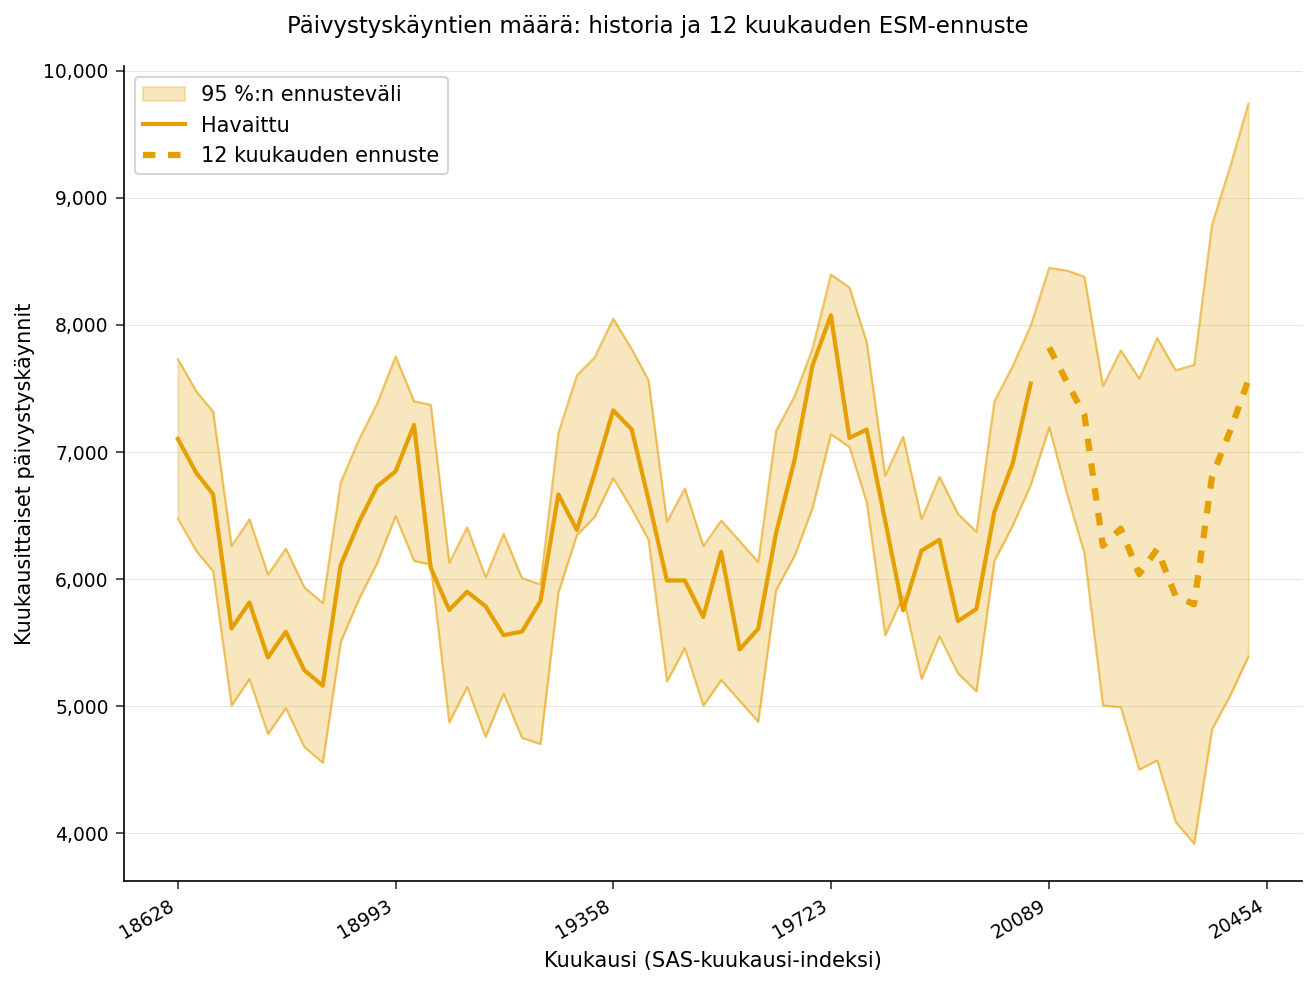

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
TIEDOT forecast_plot;
    ASETA forecast_path;
    JOS observed = . NIIN fc_only = predict;   /* future months only */
    MUUTEN fc_only = .;
SUORITA;

PROSEDUURI SGPLOT TIEDOT=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel='95 %:n ennusteväli' TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel='Havaittu';
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel='12 kuukauden ennuste';
    XAXIS NIMIKE='Kuukausi (SAS-kuukausi-indeksi)';
    YAXIS NIMIKE='Kuukausittaiset päivystyskäynnit' grid;
    OTSIKKO 'Päivystyskäyntien määrä: historia ja 12 kuukauden ESM-ennuste';
SUORITA;


## Tulosten tulkinta

Wintersin multiplikatiivinen malli hajottaa päivystyksen käyntimäärän hitaasti nousevaan **tasoon**, lähes tasaiseen **trendiin** ja vakaaseen **kausivaihteluun**. `OUTSUM=`-tietojoukosta luetut tasoituspainot kertovat tarinan: kohtalainen tasopaino (alpha = 0,30) antaa perustason ajautua ylöspäin potilasväestön kasvun mukana, kun taas pienet trendi- ja kausipainot (beta = gamma = 0,10) heijastavat sitä, että kasvuvauhti ja talven ryntäyksen muoto ovat erittäin vakaita vuodesta toiseen eikä niihin pidä ylireagoida kuukaudesta toiseen.

**Sovitustunnusluvut** vahvistavat, että malli seuraa historiaa hyvin: noin 320 käynnin RMSE ja 4,16 %:n MAPE tarkoittavat, että tyypillinen kuukausittainen virhe on alle 5 % käyntimäärästä. Operatiivisesti **ennustetaulukko ja vyöhykekuvaaja** kvantifioivat joulu-helmikuun huipun, jota kohti päivystyksen tulisi miehittää - suunnilleen 7 300-7 800 käyntiä talvikuukausina - ja 95 %:n ennustusrajat määrittävät harkitun kapasiteettivälin: suunnittele ydinmiehitys pisteennusteen mukaan ja järjestä ennalta joustopeitto ja ryntäysvuoteet ylärajaa kohti. Väli levenee horisontin myötä, joten ensi kuukauden suunnitelma on paljon vankempi kuin ensi joulukuun ja se tulisi päivittää uusien toteumien saapuessa.

**Laajennukset:** vertaa `MODEL=ADDWINTERS` (additiivinen kausivaihtelu) multiplikatiiviseen sovitukseen vahvistaaksesi multiplikatiivisen valinnan; sovella `TRANSFORM=LOG` positiivisuuden pakottamiseen ja varianssin vakauttamiseen; tai lisää `BY`-lause ennustaaksesi useita sairaalatoimipisteitä yhdellä PROC ESM -kutsulla.
